# Train logistic regression model (t+1 target)
Train a logistic regression classifier on `data/processed/log_reg_t1`, using `target_t+1` as the label and all columns except `target_t+1`, `client_nr`, and `yearmonth` as features.

Features are standardized inside the pipeline, and `class_weight="balanced"` handles the rare positive class. Hyperparameters (`C`, `penalty`) are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# make the models/ package importable from this notebook
sys.path.append(str(Path("models").resolve()))

from train_logistic_regression import (
    evaluate_all_splits,
    get_feature_columns,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,835
Validation observations: 3,790
Number of features: 33

Class distribution in training data:
  Negative: 17,507
  Positive: 1,328


Best trial: 0. Best value: 0.158337: 100%|██████████| 50/50 [00:22<00:00,  2.26it/s]



Best validation PR-AUC: 0.1583
Best hyperparameters:
  C: 0.01
  penalty: l1


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_C,params_penalty,state
0,0,0.158337,2026-08-30 22:20:34.484216,2026-08-30 22:20:34.592300,0 days 00:00:00.108084,0.01,l1,COMPLETE
34,34,0.158337,2026-08-30 22:20:52.917317,2026-08-30 22:20:53.001418,0 days 00:00:00.084101,0.01,l1,COMPLETE
22,22,0.158337,2026-08-30 22:20:47.746829,2026-08-30 22:20:47.823908,0 days 00:00:00.077079,0.01,l1,COMPLETE
23,23,0.158337,2026-08-30 22:20:47.829070,2026-08-30 22:20:47.905814,0 days 00:00:00.076744,0.01,l1,COMPLETE
24,24,0.158337,2026-08-30 22:20:47.911367,2026-08-30 22:20:47.983960,0 days 00:00:00.072593,0.01,l1,COMPLETE
27,27,0.158337,2026-08-30 22:20:48.198850,2026-08-30 22:20:48.283940,0 days 00:00:00.085090,0.01,l1,COMPLETE
31,31,0.158337,2026-08-30 22:20:52.563064,2026-08-30 22:20:52.667423,0 days 00:00:00.104359,0.01,l1,COMPLETE
33,33,0.158337,2026-08-30 22:20:52.828387,2026-08-30 22:20:52.917317,0 days 00:00:00.088930,0.01,l1,COMPLETE
37,37,0.158337,2026-08-30 22:20:53.380120,2026-08-30 22:20:53.463713,0 days 00:00:00.083593,0.01,l1,COMPLETE
17,17,0.158337,2026-08-30 22:20:46.816799,2026-08-30 22:20:46.903987,0 days 00:00:00.087188,0.01,l1,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

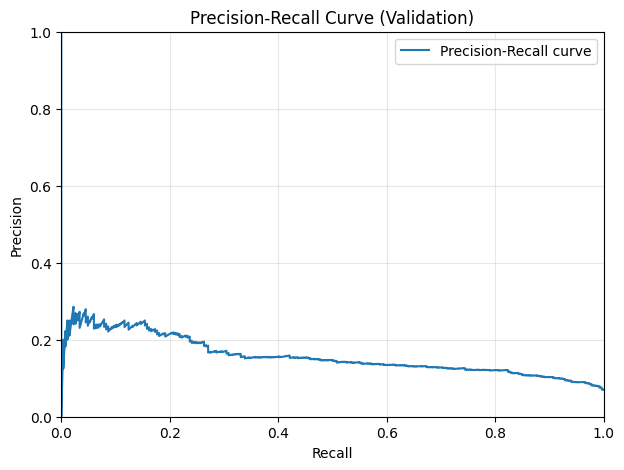

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title="Precision-Recall Curve (Validation)",
)

In [12]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.2].head(20)


,threshold,precision,recall
3475,0.746051,0.200000,0.236842
3480,0.747431,0.203226,0.236842
3478,0.746732,0.201923,0.236842
3477,0.746590,0.201278,0.236842
3481,0.747825,0.203883,0.236842
3479,0.746924,0.202572,0.236842
3482,0.747855,0.204545,0.236842
3483,0.747879,0.205212,0.236842
3484,0.748143,0.205882,0.236842
3485,0.748157,0.206557,0.236842


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

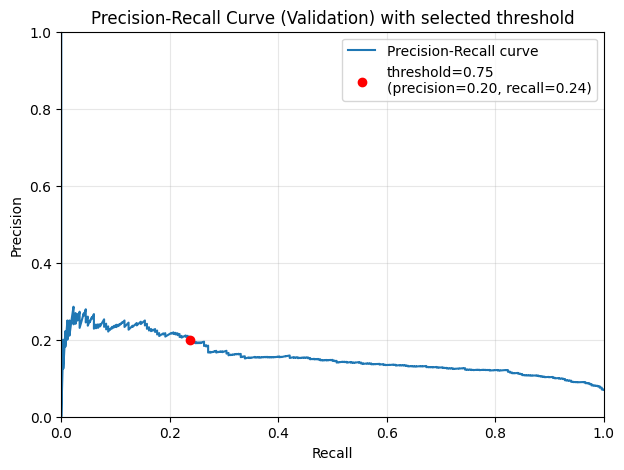

In [13]:
SELECTED_THRESHOLD = 0.746051

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title="Precision-Recall Curve (Validation) with selected threshold",
);

## Final evaluation

In [14]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.127533,0.149925,0.075301,0.100251,0.200000,0.013554
val,0.158337,0.200000,0.236842,0.216867,0.233333,0.078947
test,0.132969,0.143052,0.282258,0.189873,0.211111,0.051075


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [15]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\log_reg_t1.joblib


WindowsPath('models/artifacts/log_reg_t1.joblib')